/tmp/ipykernel_159545/317309526.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=0, fontsize=20)


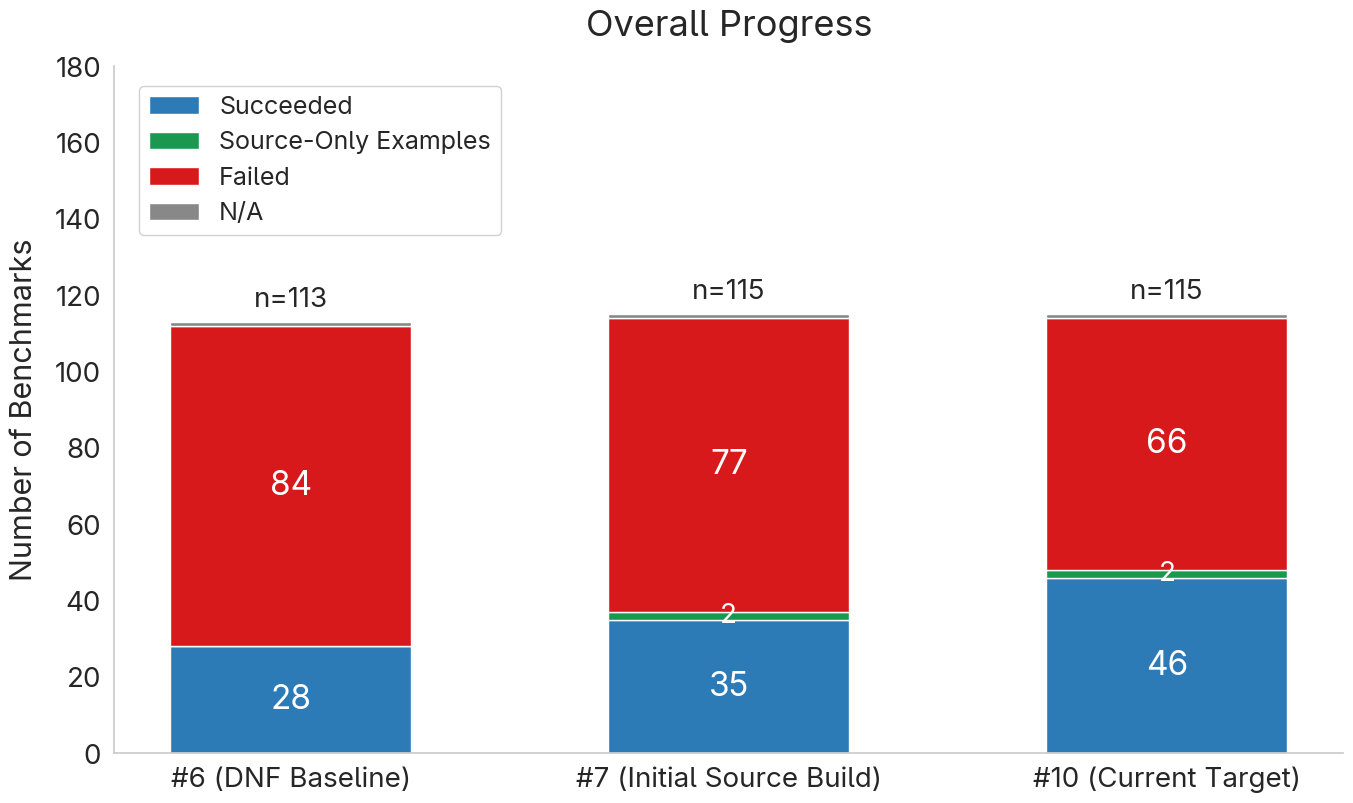

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set overall plot theme and font family
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Adwaita Sans"

fig, ax = plt.subplots(figsize=(14, 8.5))

labels = [
    "#6 (DNF Baseline)",
    "#7 (Initial Source Build)",
    "#10 (Current Target)",
]

# Color palette definition
SUCCESS_BLUE = "#2c7bb6"
EXTRA_GREEN = "#1a9850"
FAILURE_RED = "#d7191c"
NA_GREY = "#888888"

# Data series accounting for 1 N/A benchmark per run (only hip_multi_gpu_data_transfer is NA till now)
# #6 Total = 28 + 0 + 84 + 1 = 113
# #7 Total = 35 + 2 + 77 + 1 = 115
# #10 Total = 46 + 2 + 66 + 1 = 115
success_values = [28, 35, 46]
green_values = [0, 2, 2]
failure_values = [84, 77, 66]
na_values = [1, 1, 1]

# Bottom height offsets for stacking layers correctly
bottom_green = [s for s in success_values]
bottom_failure = [s + g for s, g in zip(success_values, green_values)]
bottom_na = [
    s + g + f for s, g, f in zip(success_values, green_values, failure_values)
]

# Bar layers stacked from bottom to top: Blue -> Green -> Red -> Grey
ax.bar(
    labels,
    success_values,
    color=SUCCESS_BLUE,
    label="Succeeded",
    width=0.55,
)
ax.bar(
    labels,
    green_values,
    bottom=bottom_green,
    color=EXTRA_GREEN,
    label="Source-Only Examples",
    width=0.55,
)
ax.bar(
    labels,
    failure_values,
    bottom=bottom_failure,
    color=FAILURE_RED,
    label="Failed",
    width=0.55,
)
ax.bar(
    labels,
    na_values,
    bottom=bottom_na,
    color=NA_GREY,
    label="N/A",
    width=0.55,
)

# Text labels inside bars (UNBOLDED regular font weight)
for i in range(len(labels)):
  # Blue layer
  if success_values[i] > 0:
    ax.text(
        i,
        success_values[i] / 2,
        str(success_values[i]),
        ha="center",
        va="center",
        fontsize=24,
        color="white",
        fontweight="normal",
    )
  # Green layer
  if green_values[i] >= 2:
    ax.text(
        i,
        bottom_green[i] + (green_values[i] / 2),
        str(green_values[i]),
        ha="center",
        va="center",
        fontsize=20,
        color="white",
        fontweight="normal",
    )
  # Red layer
  if failure_values[i] > 0:
    ax.text(
        i,
        bottom_failure[i] + (failure_values[i] / 2),
        str(failure_values[i]),
        ha="center",
        va="center",
        fontsize=24,
        color="white",
        fontweight="normal",
    )

  # Top n= total text (scaled up, unbolded)
  total = (
      success_values[i] + green_values[i] + failure_values[i] + na_values[i]
  )
  ax.text(i, total + 2.5, f"n={total}", ha="center", va="bottom", fontsize=20)

# Headroom expansion to prevent legend box overlap
ax.set_ylim(0, 180)

# Title & Axis Labels
ax.set_title(
    "Overall Progress",
    fontsize=26,
    pad=22,
)
ax.set_ylabel("Number of Benchmarks", fontsize=22, labelpad=12)
ax.set_xlabel("")

# Tick parameters
ax.set_xticklabels(labels, rotation=0, fontsize=20)
ax.tick_params(axis="y", labelsize=20)

# Legend setup matching requirements
legend = ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    fontsize=18,
    framealpha=0.9,
)

for text in legend.get_texts():
  text.set_fontfamily("Adwaita Sans")

ax.grid(False)
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

plt.tight_layout(pad=2.0)
plt.savefig("hip_overall_progress_clean_unbolded.png", dpi=300, bbox_inches="tight")

In [10]:
import csv
import re
from pathlib import Path

# Color constants
GREEN = "#2ece68"  # Succeeded (Standard)
BLUE = "#3498db"   # Succeeded (Source-only)
RED = "#e74c3c"    # Failed
ORANGE = "#e67e22" # DNF (Did Not Finish)
GRAY = "#95a5a6"   # N/A

CSV_6 = Path("/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-6/benchmark_results.csv")
CSV_11 = Path("/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-11/benchmark_results.csv")

def extract_binary_name(raw_path: str) -> str:
    """Extract clean binary name from full execution path or raw string."""
    if not raw_path or raw_path == "N/A":
        return "N/A"
    path_obj = Path(raw_path.strip())
    return path_obj.name

def load_data():
    # Load baseline binaries from CSV 6
    baseline_binaries = set()
    with open(CSV_6, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f, delimiter='|')
        for row in reader:
            b_name = extract_binary_name(row['binary'])
            if b_name != "N/A":
                baseline_binaries.add(b_name)

    # Process CSV 11
    results = {
        "success_std": 0,
        "success_src": 0,
        "failed": 0,
        "dnf": 0,
        "na": 0,
        "details": []
    }

    with open(CSV_11, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f, delimiter='|')
        for row in reader:
            raw_binary = row['binary']
            status = row['status'].strip().upper()
            
            clean_name = extract_binary_name(raw_binary)

            if status == "SUCCESS":
                if clean_name in baseline_binaries:
                    category = "Succeeded (Standard)"
                    color = GREEN
                    results["success_std"] += 1
                else:
                    category = "Succeeded (Source-Only)"
                    color = BLUE
                    results["success_src"] += 1
            elif status == "FAILURE":
                category = "Failed"
                color = RED
                results["failed"] += 1
            elif status == "DNF":
                category = "Did Not Finish (DNF)"
                color = ORANGE
                results["dnf"] += 1
            else:
                category = "N/A"
                color = GRAY
                results["na"] += 1

            results["details"].append({
                "binary": clean_name,
                "status": status,
                "category": category,
                "color": color,
                "execution_time_ms": row.get("execution_time_ms", "N/A"),
                "error_category": row.get("error_category", "None")
            })

    return results

if __name__ == "__main__":
    data = load_data()
    print("=== Execution Breakdown ===")
    print(f"Succeeded (Standard):    {data['success_std']}")
    print(f"Succeeded (Source-Only): {data['success_src']}")
    print(f"Failed:                  {data['failed']}")
    print(f"DNF:                     {data['dnf']}")
    print(f"N/A:                     {data['na']}")
    print(f"Total Rows Processed:    {len(data['details'])}")

=== Execution Breakdown ===
Succeeded (Standard):    65
Succeeded (Source-Only): 22
Failed:                  53
DNF:                     1
N/A:                     0
Total Rows Processed:    141


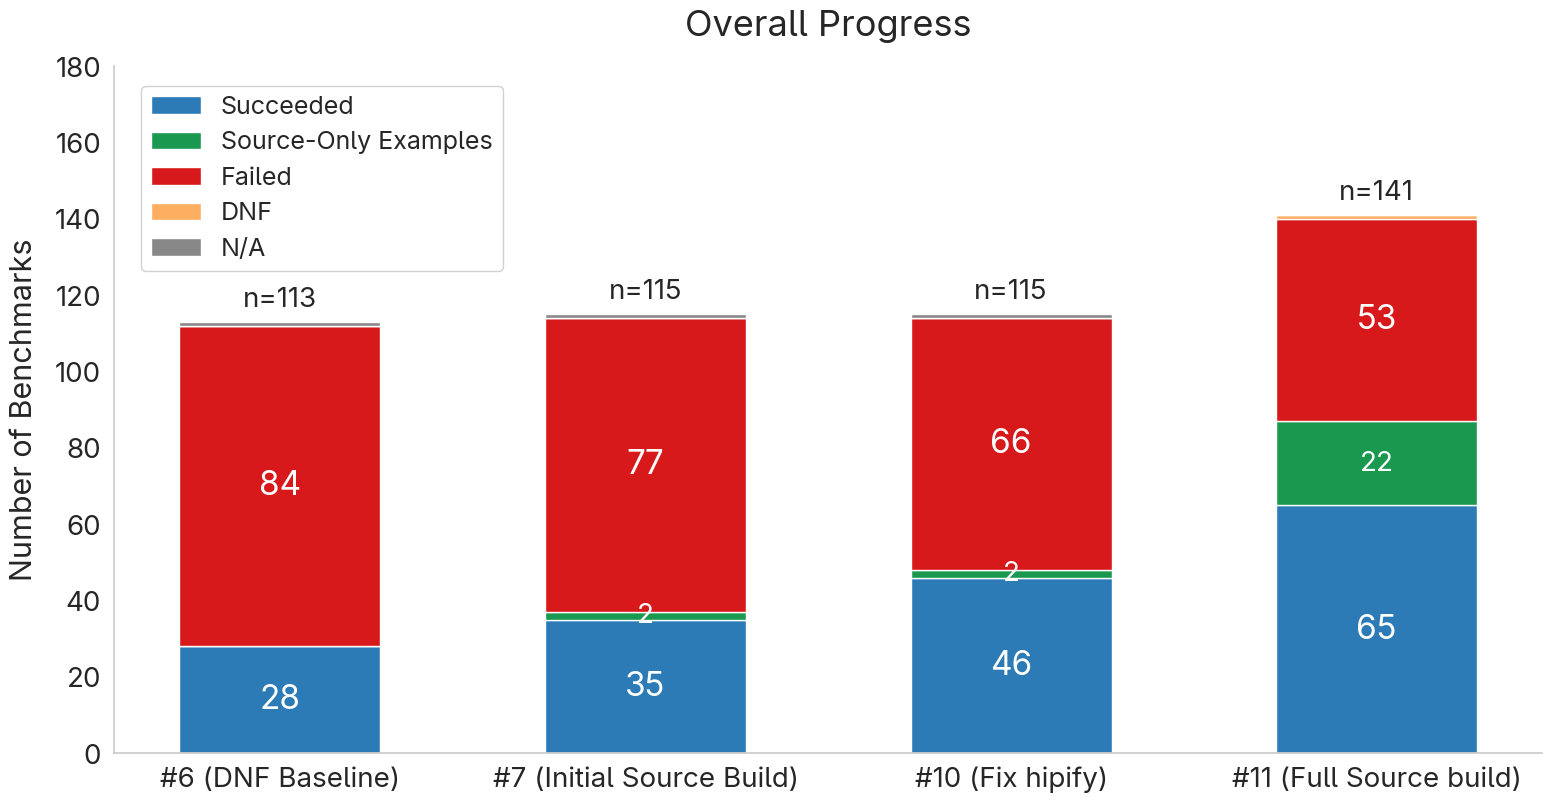

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# File paths
csv_6_path = "/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-6/benchmark_results.csv"
csv_11_path = "/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-11/benchmark_results.csv"

# Read CSVs with proper pipe delimiter
df6 = pd.read_csv(csv_6_path, sep="|")
df11 = pd.read_csv(csv_11_path, sep="|")

# Set of benchmark names present in run #6
binaries_baseline_6 = set(df6["binary"].dropna().unique())

# Identify source-only binaries present in run #11 but not in run #6
is_source_only_11 = ~df11["binary"].isin(binaries_baseline_6)

# Dynamic calculations for run #11
source_only_11 = (is_source_only_11 & (df11["status"] == "Success")).sum()
succeeded_11 = (~is_source_only_11 & (df11["status"] == "Success")).sum()
failed_11 = (df11["status"] == "Failure").sum()
dnf_11 = (df11["status"] == "DNF").sum()

# Multi-GPU succeeded in run #11, so N/A count is now 0 for run #11
na_11 = 0

# Set overall plot theme and font family
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Adwaita Sans"

fig, ax = plt.subplots(figsize=(16, 8.5))

labels = [
    "#6 (DNF Baseline)",
    "#7 (Initial Source Build)",
    "#10 (Fix hipify)",
    "#11 (Full Source build)",
]

# Color palette definition
SUCCESS_BLUE = "#2c7bb6"
EXTRA_GREEN = "#1a9850"
FAILURE_RED = "#d7191c"
DNF_ORANGE = "#fdae61"
NA_GREY = "#888888"

# Data series accounting for all 4 runs (#7 and #10 kept unchanged)
success_values = [28, 35, 46, succeeded_11]
green_values = [0, 2, 2, source_only_11]
failure_values = [84, 77, 66, failed_11]
dnf_values = [0, 0, 0, dnf_11]
na_values = [1, 1, 1, na_11]

# Bottom height offsets for stacking layers correctly
bottom_green = [s for s in success_values]
bottom_failure = [s + g for s, g in zip(success_values, green_values)]
bottom_dnf = [
    s + g + f for s, g, f in zip(success_values, green_values, failure_values)
]
bottom_na = [
    s + g + f + d
    for s, g, f, d in zip(
        success_values, green_values, failure_values, dnf_values
    )
]

# Bar layers stacked: Blue -> Green -> Red -> Orange (DNF) -> Grey (N/A)
ax.bar(
    labels, success_values, color=SUCCESS_BLUE, label="Succeeded", width=0.55
)
ax.bar(
    labels,
    green_values,
    bottom=bottom_green,
    color=EXTRA_GREEN,
    label="Source-Only Examples",
    width=0.55,
)
ax.bar(
    labels,
    failure_values,
    bottom=bottom_failure,
    color=FAILURE_RED,
    label="Failed",
    width=0.55,
)
ax.bar(
    labels,
    dnf_values,
    bottom=bottom_dnf,
    color=DNF_ORANGE,
    label="DNF",
    width=0.55,
)
ax.bar(
    labels, na_values, bottom=bottom_na, color=NA_GREY, label="N/A", width=0.55
)

# Text labels inside bars (UNBOLDED regular font weight)
for i in range(len(labels)):
  if success_values[i] > 0:
    ax.text(
        i,
        success_values[i] / 2,
        str(success_values[i]),
        ha="center",
        va="center",
        fontsize=24,
        color="white",
        fontweight="normal",
    )
  if green_values[i] >= 2:
    ax.text(
        i,
        bottom_green[i] + (green_values[i] / 2),
        str(green_values[i]),
        ha="center",
        va="center",
        fontsize=20,
        color="white",
        fontweight="normal",
    )
  if failure_values[i] > 0:
    ax.text(
        i,
        bottom_failure[i] + (failure_values[i] / 2),
        str(failure_values[i]),
        ha="center",
        va="center",
        fontsize=24,
        color="white",
        fontweight="normal",
    )

  # Top n= total text
  total = (
      success_values[i]
      + green_values[i]
      + failure_values[i]
      + dnf_values[i]
      + na_values[i]
  )
  ax.text(i, total + 2.5, f"n={total}", ha="center", va="bottom", fontsize=20)

# Headroom expansion
ax.set_ylim(0, 180)

# Title & Axis Labels
ax.set_title("Overall Progress", fontsize=26, pad=22)
ax.set_ylabel("Number of Benchmarks", fontsize=22, labelpad=12)
ax.set_xlabel("")

# Tick parameters
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=0, fontsize=20)
ax.tick_params(axis="y", labelsize=20)

# Legend setup
legend = ax.legend(
    loc="upper left", bbox_to_anchor=(0.01, 0.99), fontsize=18, framealpha=0.9
)
for text in legend.get_texts():
  text.set_fontfamily("Adwaita Sans")

ax.grid(False)
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

plt.tight_layout(pad=2.0)
plt.savefig(
    "hip_overall_progress_clean_unbolded.png", dpi=300, bbox_inches="tight"
)

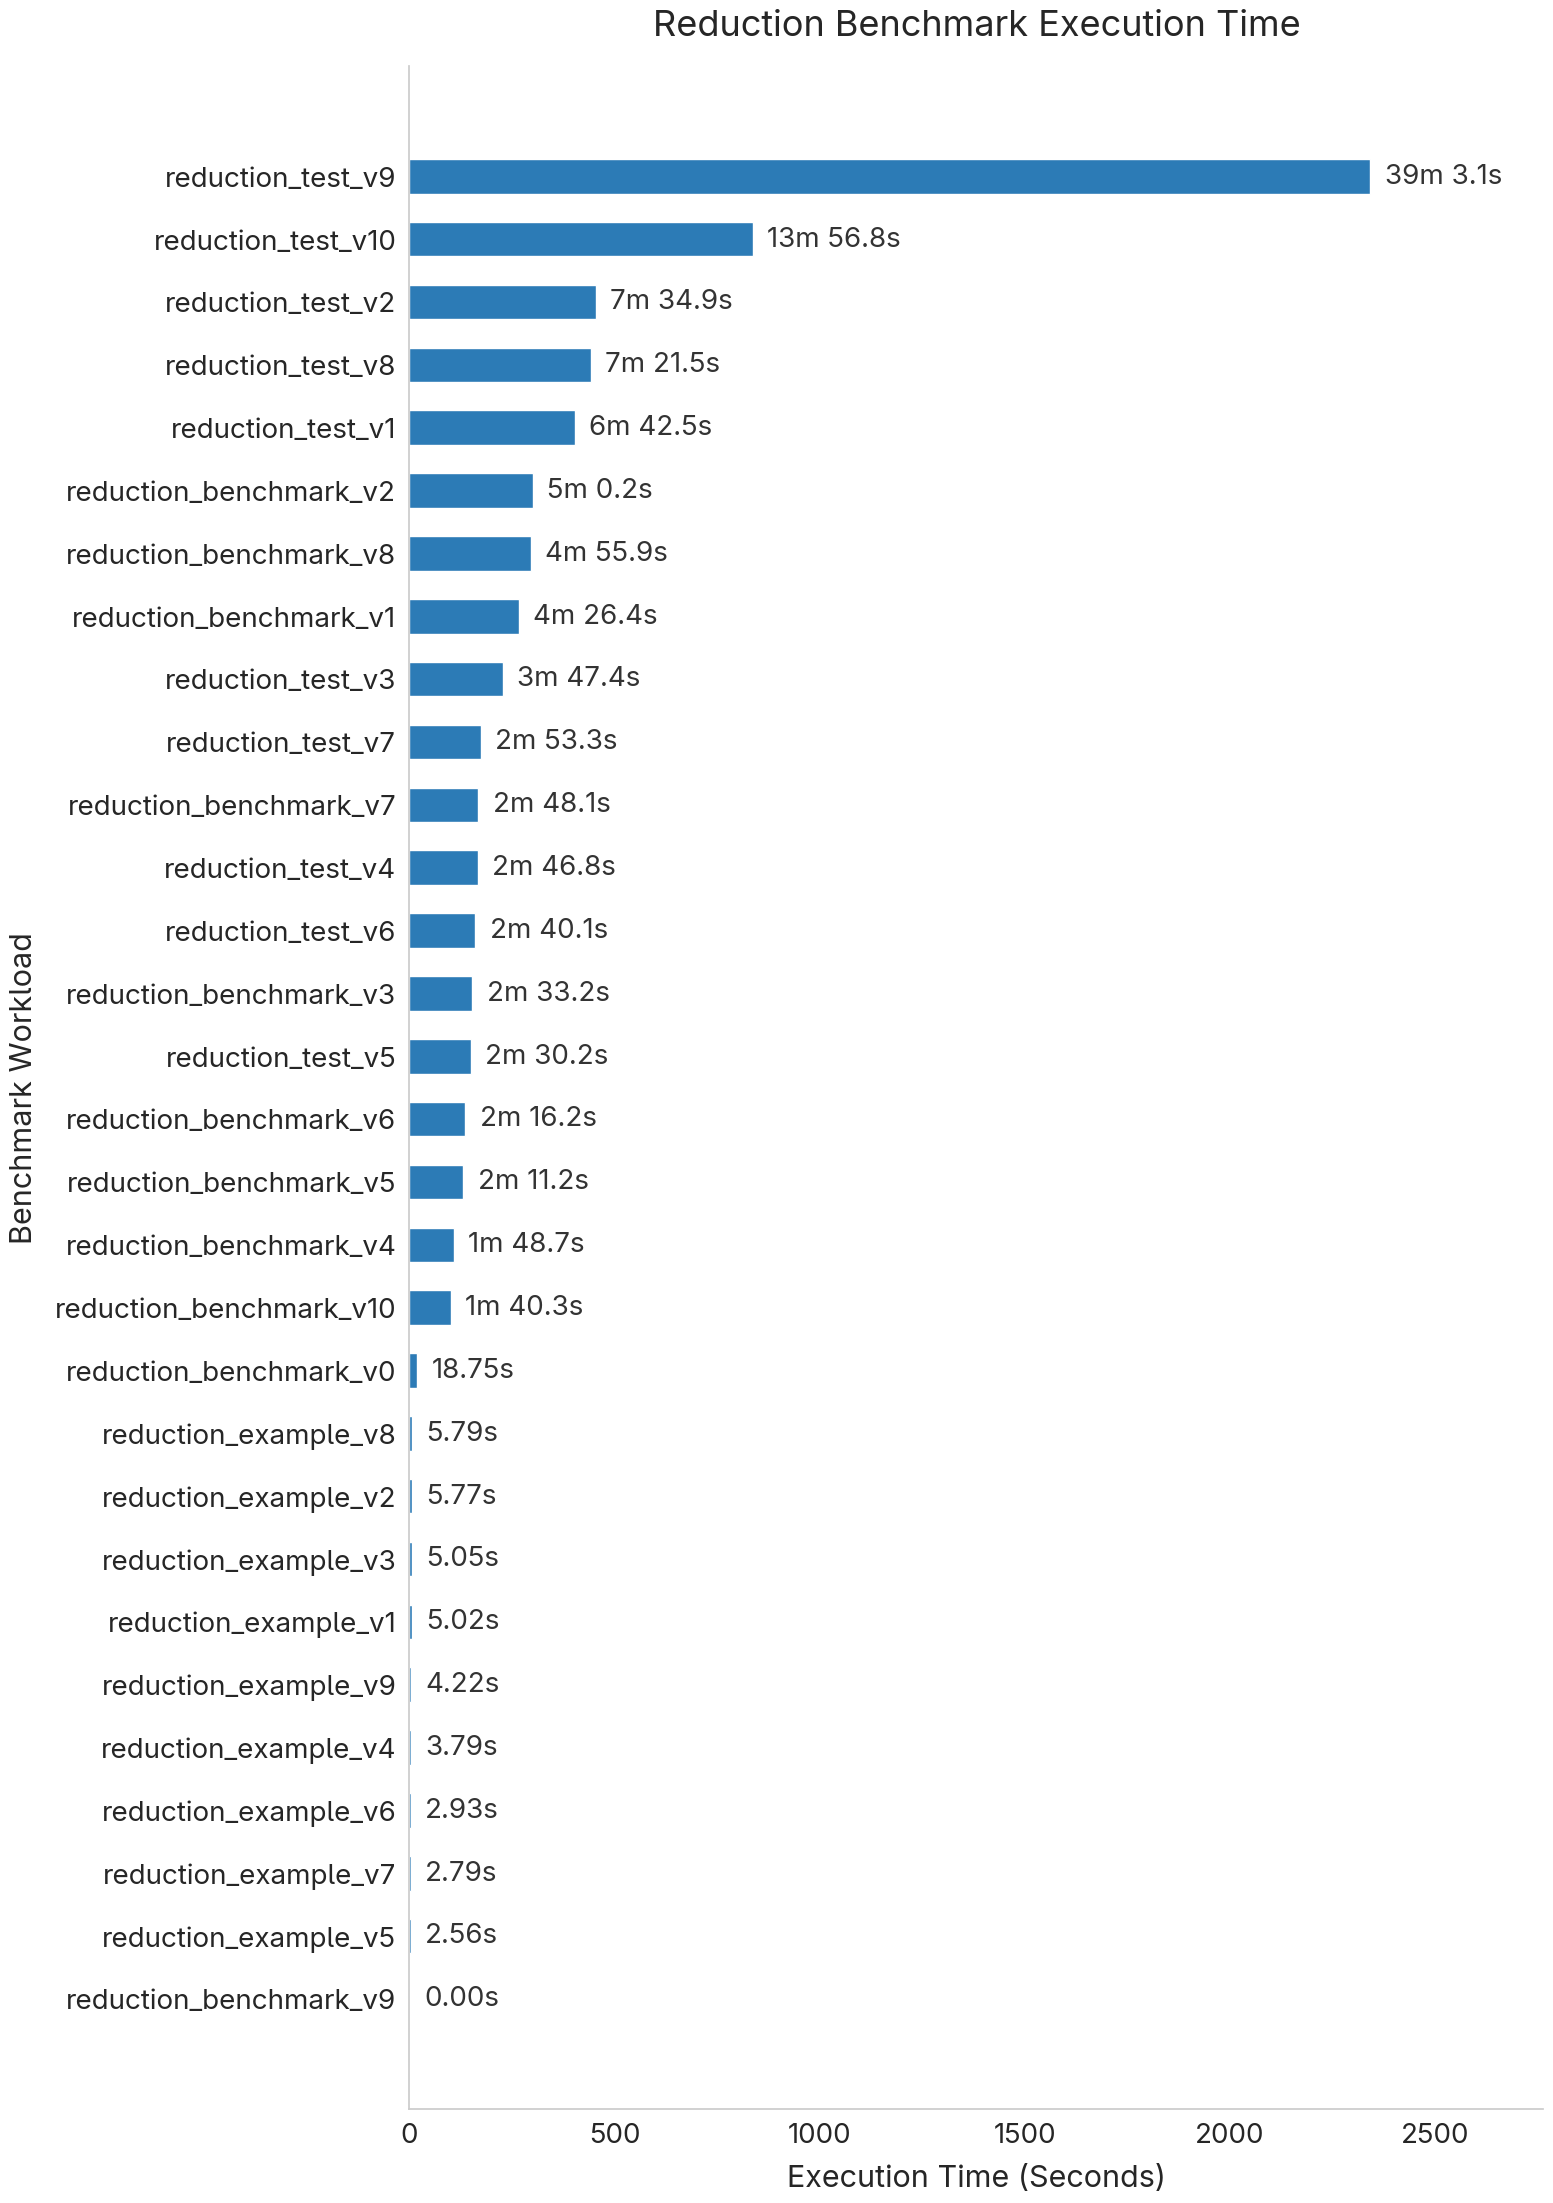

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# File path
csv_11_path = "/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-11/benchmark_results.csv"

# Read CSV with proper pipe delimiter
df11 = pd.read_csv(csv_11_path, sep="|")

# Clean column names (strip whitespace if any)
df11.columns = df11.columns.str.strip()

# Filter exclusively for reduction workloads (case-insensitive)
df_reduction = df11[
    df11["binary"].str.contains("reduction", case=False, na=False)
].copy()

# Ensure execution_time_ms is numeric
df_reduction["execution_time_ms"] = pd.to_numeric(
    df_reduction["execution_time_ms"], errors="coerce"
).fillna(0)

# Convert execution time from ms to seconds
df_reduction["execution_time_s"] = df_reduction["execution_time_ms"] / 1000.0

# Sort ascending so matplotlib places the longest execution time at the top
df_reduction = df_reduction.sort_values(
    by="execution_time_s", ascending=True
).reset_index(drop=True)


# Format helper: converts seconds to "Xm Y.Zs" or "Y.ZZs"
def format_time(seconds):
  if seconds >= 60:
    mins = int(seconds // 60)
    secs = seconds % 60
    return f"{mins}m {secs:.1f}s"
  else:
    return f"{seconds:.2f}s"


df_reduction["formatted_time"] = df_reduction["execution_time_s"].apply(
    format_time
)

# Set overall plot theme and font family
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Adwaita Sans"

# Dynamic figure height based on the number of reduction benchmarks
fig_height = max(8.5, len(df_reduction) * 0.75)
fig, ax = plt.subplots(figsize=(16, fig_height))

# Color matching primary SUCCESS_BLUE palette
SUCCESS_BLUE = "#2c7bb6"

# Horizontal bar chart plot
bars = ax.barh(
    df_reduction["binary"],
    df_reduction["execution_time_s"],
    color=SUCCESS_BLUE,
    height=0.55,
)

# Add text labels next to each horizontal bar
max_time = (
    df_reduction["execution_time_s"].max()
    if not df_reduction.empty
    else 1.0
)
for bar, time_str in zip(bars, df_reduction["formatted_time"]):
  width = bar.get_width()
  ax.text(
      width + (max_time * 0.015),
      bar.get_y() + bar.get_height() / 2.0,
      time_str,
      ha="left",
      va="center",
      fontsize=20,
      fontweight="normal",
      color="#333333",
  )

# Headroom expansion on x-axis for right-side text labels
ax.set_xlim(0, max_time * 1.18 if max_time > 0 else 10)

# Title & Axis Labels
ax.set_title("Reduction Benchmark Execution Time", fontsize=26, pad=22)
ax.set_xlabel("Execution Time (Seconds)", fontsize=22, labelpad=12)
ax.set_ylabel("Benchmark Workload", fontsize=22, labelpad=12)

# Tick parameters
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)

ax.grid(False)
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

plt.tight_layout(pad=2.0)
plt.savefig(
    "reduction_execution_time_run11.png", dpi=300, bbox_inches="tight"
)

In [26]:
from collections import defaultdict
import os
import pandas as pd
import plotly.graph_objects as go

# -------------------------------------------------------------------------
# Load and Clean Benchmark Records (#11)
# -------------------------------------------------------------------------
csv_path = "/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-11/benchmark_results.csv"
if not os.path.exists(csv_path):
  raise FileNotFoundError(f"Missing '{csv_path}'.")

df = pd.read_csv(csv_path, sep="|")
df["error_category"] = df["error_category"].fillna("Unknown Error")

# Filter out non-executed entries (e.g., DNF)
df = df[df["status"].isin(["Success", "Failure"])].copy()

# -------------------------------------------------------------------------
# Calculate Dynamic Counts
# -------------------------------------------------------------------------
total_cnt = len(df)
success_cnt = len(df[df["status"] == "Success"])
failure_cnt = len(df[df["status"] == "Failure"])
error_counts = (
    df[df["status"] == "Failure"]["error_category"].value_counts().to_dict()
)

# Base Node Labels
root_name = f"rocm-examples ({total_cnt})"
success_name = f"Success ({success_cnt})"
failure_name = f"Failure ({failure_cnt})"

# -------------------------------------------------------------------------
# Node Positions (Explicit Coordinates to prevent overlapping)
# Column 0 (x=0.001): Root
# Column 1 (x=0.500): Success (Top), Failure (Bottom)
# Column 2 (x=0.999): Error categories (Stacked below Failure)
# -------------------------------------------------------------------------
unique_nodes = [root_name, success_name, failure_name]

# Coordinates for Root, Success, Failure
node_x = [0.001, 0.500, 0.500]
node_y = [0.500, 0.100, 0.800]

# Add error category nodes positioned in Column 2 (x=0.999) stacked vertically
err_y_start = 0.45
err_y_step = 0.095

for i, (err_cat, count) in enumerate(error_counts.items()):
  label_with_count = f"{err_cat} ({count})"
  unique_nodes.append(label_with_count)
  node_x.append(0.999)
  node_y.append(err_y_start + i * err_y_step)

node_indices = {name: idx for idx, name in enumerate(unique_nodes)}

# -------------------------------------------------------------------------
# Build Aggregated Flows
# -------------------------------------------------------------------------
flows = []
flows.append((root_name, success_name, success_cnt))
flows.append((root_name, failure_name, failure_cnt))

for err_cat, count in error_counts.items():
  label_with_count = f"{err_cat} ({count})"
  flows.append((failure_name, label_with_count, count))

plotly_sources = [node_indices[src] for src, tgt, val in flows]
plotly_targets = [node_indices[tgt] for src, tgt, val in flows]
plotly_values = [val for src, tgt, val in flows]

# -------------------------------------------------------------------------
# Color Mapping
# -------------------------------------------------------------------------
color_map = {
    "neutral": "rgba(100, 116, 139, 0.85)",
    "success": "rgba(44, 123, 182, 0.85)",
    "failure": "rgba(215, 25, 28, 0.85)",
    "error": "rgba(239, 68, 68, 0.75)",
    "flow_success": "rgba(44, 123, 182, 0.30)",
    "flow_failure": "rgba(215, 25, 28, 0.30)",
}

node_colors = []
for name in unique_nodes:
  if name == root_name:
    node_colors.append(color_map["neutral"])
  elif name == success_name:
    node_colors.append(color_map["success"])
  elif name == failure_name:
    node_colors.append(color_map["failure"])
  else:
    node_colors.append(color_map["error"])

link_colors = []
for s_idx, t_idx in zip(plotly_sources, plotly_targets):
  target_name = unique_nodes[t_idx]
  if target_name == success_name:
    link_colors.append(color_map["flow_success"])
  else:
    link_colors.append(color_map["flow_failure"])

# -------------------------------------------------------------------------
# Render Plotly Sankey Figure
# -------------------------------------------------------------------------
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",  # Strictly respects explicit x and y coordinates
            node=dict(
                pad=20,
                thickness=20,
                line=dict(color="rgba(255, 255, 255, 0.9)", width=0.5),
                label=unique_nodes,
                color=node_colors,
                x=node_x,
                y=node_y,
            ),
            link=dict(
                source=plotly_sources,
                target=plotly_targets,
                value=plotly_values,
                color=link_colors,
            ),
        )
    ]
)

fig.update_layout(
    title_text=(
        f"rocm-examples failure modes"
    ),
    title_font=dict(size=24, family="Adwaita Mono, monospace", color="#1e293b"),
    font_size=16,
    font_family="Adwaita Sans, sans-serif",
    width=1400,
    height=850,
    plot_bgcolor="white",
    paper_bgcolor="white",
)

sankey_output = "rocm_simplified_outcome_sankey.png"
fig.write_image(sankey_output, scale=2)
print(f"Sankey saved to: {sankey_output}")
fig.show()

Sankey saved to: rocm_simplified_outcome_sankey.png
